# data generation on implicit method 

In [ ]:

import jax
import numpy as np
import jax.random as random
import jax.numpy as jnp
import jax.numpy.fft as jfft
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure
from numpy import sqrt
from numpy import round
from matplotlib import pyplot as plt
from matplotlib import contour
from jax.numpy.fft import fft2, ifft2
from jax.numpy.fft import fftn, ifftn
from numpy import real
from jax.example_libraries.stax import serial, Gelu
from jax.example_libraries.optimizers import optimizer, make_schedule
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter

import os 
# @partial(jit, static_argnums=(0,))
def allen_cahn_implicit(uk, pp2, qq2, dt, eps, Nt, max_iter=50, tolerance=1e-6):
    cahn = eps**2
    samples_timesteps = []

    for iter in range(0, Nt + 1):
        uk = jnp.real(uk)

        # Compute denominator in Fourier space (it depends on the next state)
        denominator = cahn + dt * (2 + cahn * (pp2 + qq2))

        # Initial guess for uk(t+1) (you could use uk(t) or another initial guess)
        uk_next = uk.copy()

        # Fixed-point iteration to solve for uk(t+1)
        for i in range(max_iter):
            # Compute the nonlinear term using the current guess for uk(t+1)
            s_hat = jfft.fft2(cahn * uk_next - dt * (uk_next**3 - 3 * uk_next))  # Nonlinear term

            # Update the guess for uk(t+1) using the implicit update
            uk_next_new = s_hat / denominator  # Implicit update step

            # Check for convergence (using L2 norm)
            if jnp.linalg.norm(uk_next_new - uk_next) < tolerance:
                print(f"Converged after {i+1} iterations.")
                break

            # Update the guess for the next iteration
            uk_next = uk_next_new

        # Inverse FFT to get the updated solution in real space
        uk = jfft.ifft2(uk_next)
        uk = jnp.real(uk)

        # Collect the solution at certain time steps
        if iter % 1000 == 0:
            samples_timesteps.append(uk)

        print(f"Sample {iter} completed")
    
    return jnp.array(samples_timesteps)






# difinning the no of grid points in x, y and z
Nx = 28 # number of grid points in x be positive even integer number
Ny = 28 # number of grid points in y be positive even integer number



# Define the parameters of the Allen-Cahn equation in 2d
Lx = 2.0 * jnp.pi #length of the domain in x
Ly = 2.0 * jnp.pi #length of the domain in y
hx = Lx / Nx #spatial step size in coordinate x
hy = Ly / Ny #spatial step size in coordinate y
dt = 0.0001 #time step size increase the time step size to 0.01(10times bigger than explcit method)
T = 4 #final time
Nt = int(jnp.round(T/dt)) #number of time steps
ns = Nt / 10 #number of snapshots

# Define the grid points in x and y direction
def x_gridpoint(Nx, Lx, hx):
    x = jnp.linspace(-0.5*Lx+hx,0.5*Lx,Nx)
    return x
x = x_gridpoint(Nx, Lx, hx) #number of grid points in x direction and step size and limitation on x  axis
def y_gridpoint(Ny, Ly, hy):
    y = jnp.linspace(-0.5*Ly+hy,0.5*Ly,Ny)
    return y
y = y_gridpoint(Ny, Ly, hy) #number of grid points in y direction and step size and limitation on y  axis 

# creating meshgrid in x and y direction
xx,yy = jnp.meshgrid(x,y) #creating meshgrid in x and y direction 

epsillon = 0.5 #small parameter # interface thickness in the Allen-Cahn equation 
cahn = epsillon**2 #cahn number  

theta = jnp.arctan2(yy, xx)
  # or another appropriate value
uk = jnp.tanh((1.7 + 1.2 * np.cos(6 * theta)) - jnp.sqrt(xx**2 + yy**2) / (jnp.sqrt(2) * epsillon))
# data = np.load('../data_generation_checking/phasefield2d_data_28x28_10k.npy')
data = jnp.real(uk)
# # Select 1,000 random samples
# key = jax.random.PRNGKey(0)  # Random seed for reproducibility
# idx = jax.random.choice(key, data.shape[0], shape=(10,), replace=False)  # Random 1k indices
# input_samples = data[idx]  # Shape: (1000, Nx, Ny)
input_samples = data
# print(f'uk ko shape:{uk.shape}')


# defining the wavenumber in x and y direction , which is in fourier space
p = jnp.concatenate([2 * jnp.pi / Lx * jnp.arange(0, Nx//2), 2 * jnp.pi / Lx * jnp.arange(-Nx//2  , 0)]) # wavenumber in x direction
q = jnp.concatenate([2 * jnp.pi / Ly * jnp.arange(0, Ny//2), 2 * jnp.pi / Ly * jnp.arange(-Ny//2 , 0)])


# square of wavenumber in x and y direction
p2 = p**2 # square of wavenumber in x direction
q2 = q**2 # square of wavenumber in y direction

# creating meshgrid in x and y direction for square of wavenumber
pp2, qq2 = jnp.meshgrid(p2, q2)


input_samples= input_samples.reshape(-1, Nx , Ny)

samples = []

# this for to see the how many samples are printed 
for i, uk in enumerate (input_samples):
    print(f'sample {i} started')

# for uk in input_samples:
   
    ac_input = allen_cahn_implicit(uk, pp2, qq2, dt, epsillon, Nt)
# print(f'shape of ac_input:{ac_input.shape}')
    samples.append(ac_input)
samples = jnp.array(samples)
# print(f'samples ko shape:{samples.shape}')
      

# Specify the directory where y want to save the data
save_dir = './data_driven/data/implicit'

    # Ensure the directory exists, create it if not
os.makedirs(save_dir, exist_ok=True)

#saving the data 
# Save the training and testing data
# print("Saving training data to u_train.npy...")
np.save(os.path.join(save_dir, "driven_data_28x28_circle_input_samples_21timestep_every2kiter_implicit.npy"), np.array(input_samples))
np.save(os.path.join(save_dir, "driven_data_28x28_circle_41timestep_every2kiter_implicit.npy"), np.array(samples))

# loaded the generated data
loaded_input_samples = np.load(os.path.join(save_dir, "driven_data_28x28_circle_input_samples_21timestep_every2kiter_implicit.npy"))
print(f'loaded_input_samples ko shape:{loaded_input_samples.shape}')

loaded_samples = np.load(os.path.join(save_dir, "driven_data_28x28_circle_41timestep_every2kiter_implicit.npy"))
print(f'loaded_samples ko shape:{loaded_samples.shape}')

# visulized the generated data

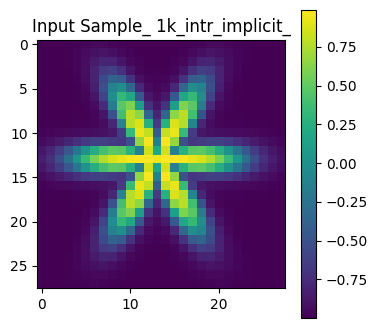

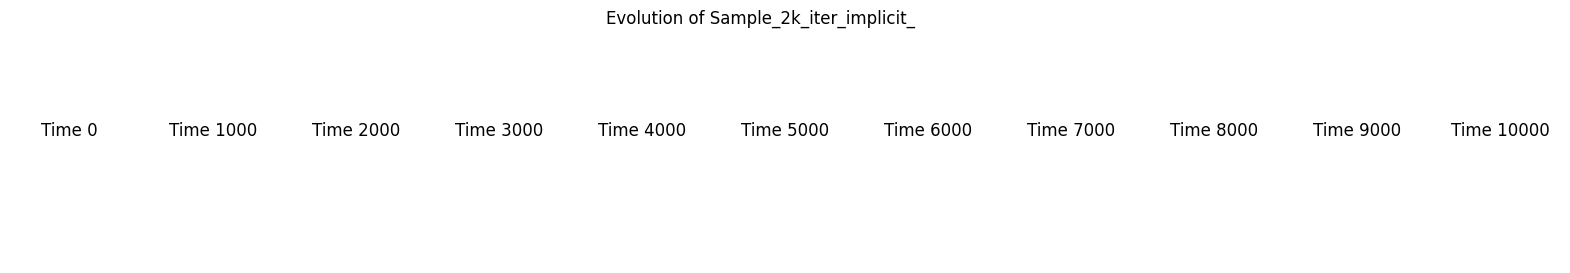

In [21]:
import numpy as np
import os
import matplotlib.pyplot as plt

save_dir = './data_driven'

# Choose a sample index
# sample_idx = 1  # Valid index within the range of 0 to 9

# Define the directory
plot_save_dir = os.path.join(save_dir,  "data_driven_plot")

# Create the directory if it doesn't exist
os.makedirs(plot_save_dir, exist_ok=True)


# Plot input data
plt.figure(figsize=(4, 4))
plt.imshow(loaded_input_samples[0], cmap='viridis')
plt.colorbar()
plt.title(f'Input Sample_ 1k_intr_implicit_')
plt.savefig(os.path.join(plot_save_dir, f'input_sample_1k_iter_implicit_.png')) 
plt.show()


# Choose a sample index
# sample_idx = 9  # Valid index within the range of 0 to 9

fig, axes = plt.subplots(1, 11, figsize=(20, 4))  # 11 time steps

for t in range(11):
    axes[t].imshow(loaded_samples[0, t], cmap='viridis')
    axes[t].set_title(f'Time {t * 1000}')
    axes[t].axis('off')

plt.suptitle(f'Evolution of Sample_2k_iter_implicit_')
plt.savefig(os.path.join(plot_save_dir, f'Evolution_sample_1k_iter_implicit_.png'))
plt.show()



# import matplotlib.animation as animation

# fig, ax = plt.subplots()
# im = ax.imshow(loaded_samples[sample_idx, 0], cmap='viridis')

# def update(frame):
#     im.set_array(loaded_samples[sample_idx, frame])
#     ax.set_title(f'Time Step: {frame * 2000}')
#     return im,

# ani = animation.FuncAnimation(fig, update, frames=11, interval=500)

# # ani.save(evolution_animation.gif', writer='pillow')  # Save as GIF
# plt.show()
